#Hodgkin–Huxley and Fitzhugh–Nagumo (FHN) Models

**4.2 PDE Model**

The FHN PDE is

$$\frac{\partial u}{\partial t} = D\frac{\partial^2 u}{\partial x^2} - u(1 - u)(a - u) \qquad (4.1a)$$

where $a$ and $D$ are arbitrary constants with $0 \leq a \leq 1$, $D > 0$. Note, in particular, the cubic nonlinearity in $u$.

The following traveling wave solution to eq. (4.1) ([2], pp 166–171; [6], p4) is used to evaluate the numerical solution

$$u(x,t) = \frac{1}{1 + \exp\left[\frac{x}{\sqrt{2D}} + \left(a - \frac{1}{2}\right)t\right]} \qquad (4.2a)$$

Eq. (4.2a) is used to specify the IC for eq. (4.1) at $t = 0$.

$$u(x,t = 0) = \frac{1}{1 + \exp\left[\frac{x}{\sqrt{2D}}\right]} \qquad (4.1b)$$

Also, boundary conditions (BCs) for eq. (4.1a) discussed subsequently include Neumann BCs that require the derivative $\partial u(x,t)/\partial x$. This derivative from eq. (4.2a) is

$$\frac{\partial u(x,t)}{\partial x} = \frac{-\exp\left[\frac{x}{\sqrt{2D}} + \left(a - \frac{1}{2}\right)t\right]\frac{1}{\sqrt{2D}}}{\left\{1 + \exp\left[\frac{x}{\sqrt{2D}} + \left(a - \frac{1}{2}\right)t\right]\right\}^2} \qquad (4.2b)$$

# Solving the 1D Single-Equation FHN Model using the Method of Lines (MOL)

The simplified, single-equation FitzHugh-Nagumo (FHN) model is a classic reaction-diffusion equation. It models the propagation of a traveling wave using a single scalar variable $u(x,t)$.

The continuous Partial Differential Equation (PDE) is given by:

$$\frac{\partial u}{\partial t} = D\frac{\partial^2 u}{\partial x^2} - u(1 - u)(a - u)$$

Where:
* $u(x,t)$ is the state variable (e.g., voltage or concentration).
* $D$ is the diffusion coefficient ($D > 0$).
* $a$ is the excitation threshold ($0 \leq a \leq 1$).
* $D\frac{\partial^2 u}{\partial x^2}$ is the spatial diffusion term.
* $-u(1 - u)(a - u)$ is the non-linear cubic reaction term.

The **Method of Lines (MOL)** solves this PDE by discretizing the spatial dimension ($x$) while leaving the time dimension ($t$) continuous. This transforms the single PDE into a large system of coupled Ordinary Differential Equations (ODEs).

### Step 1: Spatial Discretization
We divide the 1D continuous spatial domain into a grid of $N$ discrete nodes, separated by a uniform distance $\Delta x$.

Instead of searching for a continuous continuous surface $u(x,t)$, we now track a vector of continuous time-dependent variables $u_i(t)$, where $u_i$ represents the value of $u$ at the specific spatial coordinate $x_i$.

### Step 2: Approximating the Spatial Derivative
We must replace the continuous spatial derivative ($\frac{\partial^2 u}{\partial x^2}$) with an algebraic approximation. We use the standard second-order central finite difference method, which calculates the concavity at a node by looking at its immediate left and right neighbors:

$$\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2}$$

### Step 3: Transforming into a System of ODEs
We substitute this spatial approximation back into the original PDE. The spatial derivative is mathematically eliminated, leaving us with an Ordinary Differential Equation strictly with respect to time for each internal node $i$:

$$\frac{du_i}{dt} = D \left( \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2} \right) - u_i(1 - u_i)(a - u_i)$$

### Step 4: Applying Boundary Conditions
For the nodes at the very edges of the domain ($i=1$ and $i=N$), the finite difference formula cannot be applied directly because they lack a neighbor on one side.
* **Dirichlet Conditions:** If the boundaries are mathematically fixed at a constant value, their rate of change is zero: $\frac{du_1}{dt} = 0$ and $\frac{du_N}{dt} = 0$.
* **Neumann (Zero-Flux) Conditions:** If nothing can diffuse out of the domain, the slope at the boundary is zero. We use "ghost nodes" ($u_0 = u_2$) to modify the finite difference formula at the edges, ensuring the derivative remains zero.

### Conclusion
By applying this method across a grid of $N$ points, the original PDE problem is successfully converted into a system of $N$ coupled ODEs. You can now pass this system to any standard programmatic ODE solver to integrate forward through time and calculate the traveling wave.

**Boundary Conditions in the 1D FHN Model (`ncase` selector)**

In the numerical solution of Partial Differential Equations (PDEs) using the Method of Lines (MOL), boundary conditions (BCs) dictate how the edges of the spatial domain behave. Without them, the spatial derivative approximations (like central finite differences) cannot be calculated at the very first and last grid points.

The `ncase` variable acts as a switch to apply five distinct boundary conditions to the 1D FitzHugh-Nagumo model. Here is a detailed breakdown of each case:

**`ncase = 1`: Analytical Dirichlet**

**Concept:** A Dirichlet boundary condition explicitly defines the *value* of the function at the boundary. "Analytical" means we force the boundaries to perfectly match the exact mathematical traveling wave solution at every time step.
**Mathematics:** $u(x_0, t) = u_{exact}(x_0, t)$ and $u(x_N, t) = u_{exact}(x_N, t)$
**Implementation:** The time derivative at the interior nodes is calculated normally using the PDE. However, the time derivatives at the boundary nodes ($\frac{du_0}{dt}$ and $\frac{du_N}{dt}$) are explicitly calculated using the derivative of the exact analytical solution (Eq 4.2a).
**Physical Meaning:** This forces the edges of your simulation grid to behave as if they are part of a perfect, infinite traveling wave, minimizing reflections or edge artifacts.

**`ncase = 2`: Constant Dirichlet**

**Concept:** This is a simpler Dirichlet condition where the boundary values are locked to specific constant numbers and never change over time.
**Mathematics:**
$u(x_0, t) = 1$ and $u(x_N, t) = 0$
**Implementation:** The time derivative for the interior nodes is calculated using the PDE. Because the boundaries are constant, their time derivatives are forced to zero: $\frac{du_0}{dt} = 0$ and $\frac{du_N}{dt} = 0$.
**Physical Meaning:** You are permanently pinning the left edge of the domain to a fully excited state (1) and the right edge to a resting state (0).

** `ncase = 3`: Analytical Neumann**
**Concept:** A Neumann boundary condition dictates the *slope* (spatial derivative) at the boundary, rather than the value itself. "Analytical" means we force the slope at the boundaries to match the exact mathematical slope of the traveling wave.
**Mathematics:**
$\frac{\partial u}{\partial x} \big|_{x_0, t} = \frac{\partial u_{exact}}{\partial x} \big|_{x_0, t}$
**Implementation:** We calculate the exact spatial derivative from the analytical solution (Eq 4.2b). We then use this exact slope to dynamically calculate the value of the "ghost nodes" outside our domain. These ghost nodes are fed into the central difference formula to calculate the second derivative at the boundaries. The PDE is then evaluated across the *entire* grid, allowing the actual boundary values to fluctuate.
**Physical Meaning:** Like Case 1, this attempts to simulate an infinite domain by perfectly matching the expected slope of the wave as it enters or leaves the simulation window.

**`ncase = 4`: Homogeneous Neumann (Zero-Flux)**
**Concept:** This states that the slope at the boundaries is exactly zero.
**Mathematics:**
$\frac{\partial u}{\partial x} \big|_{x_0, t} = 0$ and $\frac{\partial u}{\partial x} \big|_{x_N, t} = 0$
**Implementation:** To achieve a zero slope, the ghost node perfectly mirrors the first interior node ($u_{-1} = u_1$). When substituted into the finite difference formula for the boundary node, it simplifies to $u_{xx} = \frac{2(u_1 - u_0)}{\Delta x^2}$.
**Physical Meaning:** This represents an insulated boundary. No concentration or "voltage" can diffuse into or out of the domain. When a wave hits this boundary, it will not pass through; it will stop and potentially reflect.

**`ncase = 5`: Frozen Boundaries (No Applied BCs)**
**Concept:** In this specific code structure, Case 5 calculates the PDE for the interior points but explicitly sets the time derivatives of the boundaries to zero, without locking them to a predefined mathematical equation like in Case 1 or Case 2.
**Mathematics:**
$\frac{du_0}{dt} = 0$ and $\frac{du_N}{dt} = 0$
**Implementation:** It simply bypasses updating the boundaries. The boundary values will remain exactly what they were set to at $t=0$ (the initial conditions).
**Physical Meaning:** This is essentially a Constant Dirichlet condition, but instead of forcing arbitrary values like 1 and 0, it simply freezes the edges at whatever state they started in.

In [32]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

In [33]:
def fhn_pde(t, u, D, a, ncase, dx, x):
    """
    Evaluates the time derivative for the 1D FHN PDE with varying boundary conditions.
    """
    nx = len(u)
    dudt = np.zeros(nx)
    uxx = np.zeros(nx)

    # 1. Central difference for interior points
    uxx[1:-1] = (u[2:] - 2 * u[1:-1] + u[:-2]) / (dx**2)

    # 2. Apply PDE and Boundary Conditions
    if ncase == 1:
        # Analytical Dirichlet: Boundaries are fixed to the exact traveling wave solution
        dudt[1:-1] = D * uxx[1:-1] - u[1:-1] * (1 - u[1:-1]) * (a - u[1:-1])

        # Exact time-derivative of Eq 4.2a at boundaries
        term_L = x[0] / np.sqrt(2*D) + (a - 0.5) * t
        dudt[0] = -np.exp(term_L) * (a - 0.5) / (1 + np.exp(term_L))**2

        term_R = x[-1] / np.sqrt(2*D) + (a - 0.5) * t
        dudt[-1] = -np.exp(term_R) * (a - 0.5) / (1 + np.exp(term_R))**2

    elif ncase == 2:
        # Constant Dirichlet: Left is fixed at 1, Right is fixed at 0
        dudt[1:-1] = D * uxx[1:-1] - u[1:-1] * (1 - u[1:-1]) * (a - u[1:-1])
        dudt[0] = 0.0
        dudt[-1] = 0.0

    elif ncase == 3:
        # Analytical Neumann: Slope at boundaries matches the exact derivative (Eq 4.2b)
        term_L = x[0] / np.sqrt(2*D) + (a - 0.5) * t
        ux_L = -np.exp(term_L) * (1 / np.sqrt(2*D)) / (1 + np.exp(term_L))**2
        u_ghost_L = u[1] - 2 * dx * ux_L
        uxx[0] = (u[1] - 2 * u[0] + u_ghost_L) / (dx**2)

        term_R = x[-1] / np.sqrt(2*D) + (a - 0.5) * t
        ux_R = -np.exp(term_R) * (1 / np.sqrt(2*D)) / (1 + np.exp(term_R))**2
        u_ghost_R = u[-2] + 2 * dx * ux_R
        uxx[-1] = (u_ghost_R - 2 * u[-1] + u[-2]) / (dx**2)

        dudt = D * uxx - u * (1 - u) * (a - u)

    elif ncase == 4:
        # Homogeneous Neumann: Zero flux (slope is 0 at boundaries)
        uxx[0] = 2 * (u[1] - u[0]) / (dx**2)
        uxx[-1] = 2 * (u[-2] - u[-1]) / (dx**2)
        dudt = D * uxx - u * (1 - u) * (a - u)

    elif ncase == 5:
        # No BCs applied / Boundaries frozen at t=0 values
        dudt[1:-1] = D * uxx[1:-1] - u[1:-1] * (1 - u[1:-1]) * (a - u[1:-1])
        dudt[0] = 0.0
        dudt[-1] = 0.0

    return dudt


### **BDF** / **Backward Differentiation Formula**.

In `scipy.integrate.solve_ivp`, **BDF** stands for **Backward Differentiation Formula**.


1. The Core Difference: Explicit vs. Implicit Methods

Most standard ODE solvers (like the default `RK45` in SciPy) are **explicit** methods. BDF is an **implicit** method.

* **Explicit Methods (e.g., RK45):** They calculate the *future* state of the system using only information from the *current* and *past* states.
* *The Math (Euler example):* $y_{t+1} = y_t + \Delta t \cdot f(t, y_t)$
* *The Vibe:* "I know my current speed and position, so I'll blindfold myself, walk forward for 1 second, and see where I end up."
* *Pros/Cons:* Computationally very fast per step, but prone to blowing up (becoming unstable) if the step size $\Delta t$ is too large.


* **Implicit Methods (e.g., BDF):** They calculate the future state by defining an equation that involves the *future state itself*, and then algebraically solving for it.
* *The Math (Backward Euler example):* $y_{t+1} = y_t + \Delta t \cdot f(t+1, \mathbf{y_{t+1}})$
* *The Vibe:* "I need to end up at a specific point in the future where the slope exactly points back to where I am right now."
* *Pros/Cons:* Requires solving a complex root-finding problem (like Newton's Method) at *every single time step*, making each step computationally expensive. However, it is **incredibly stable**, even with massive time steps.



### 2. What is "Stiffness"?

A system of ODEs is considered "stiff" when the equations dictate that the solution should be changing very slowly, but the underlying mathematical terms allow for extremely rapid, high-frequency oscillations.

If you use an explicit solver (RK45) on a stiff system, the solver will detect these microscopic, rapid changes and panic. To prevent the simulation from exploding to infinity (numerical instability), the solver will automatically shrink its time step $\Delta t$ to an astronomically small number. Your simulation might take weeks to compute a few seconds of simulated time.

### 3. Why MOL creates massive Stiffness

When we used the Method of Lines on the FitzHugh-Nagumo model, we approximated the diffusion term like this:

$$\frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2}$$

Look closely at the denominator: $\Delta x^2$.
If we want a high-resolution simulation, we make $\Delta x$ very small (e.g., $0.01$).
Squaring that makes it even smaller ($0.0001$).
Because it is in the denominator, dividing by $0.0001$ acts as a massive multiplier ($10,000\times$) on the ODE.

This massive multiplier means that the spatial nodes are incredibly tightly coupled. If node $u_i$ changes by even a fraction of a decimal, the equations immediately try to violently pull $u_{i+1}$ and $u_{i-1}$ along with it.

**This tight spatial coupling creates severe mathematical stiffness.**

Solving Case 1: Analytical Dirichlet...
Solving Case 2: Constant Dirichlet...
Solving Case 3: Analytical Neumann...
Solving Case 4: Homogeneous Neumann...
Solving Case 5: No Boundary Conditions (Frozen)...


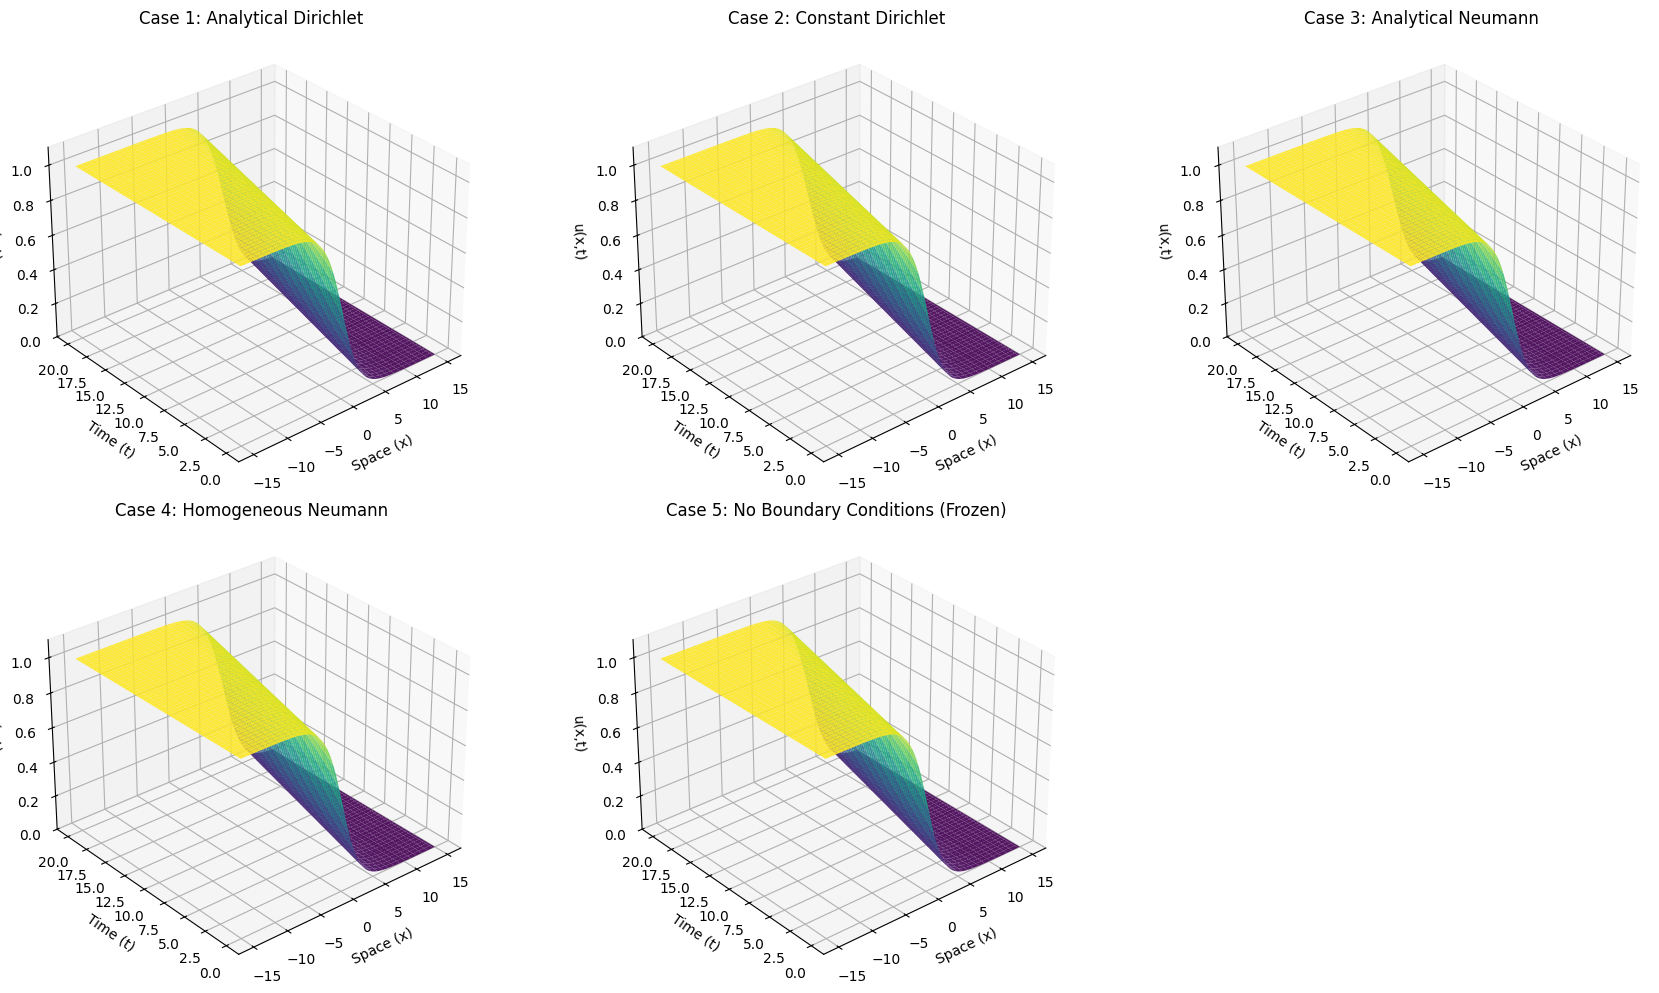

In [34]:

# ==========================================
# Simulation Parameters
# ==========================================
D = 1.0             # Diffusion coefficient
a = 0.25            # Threshold parameter
nx = 101            # Number of spatial grid points
x = np.linspace(-15, 15, nx)  # Spatial domain (centered around 0 to see the wave)
dx = x[1] - x[0]

t_span = (0, 20)    # Simulate from t=0 to t=20
t_eval = np.linspace(t_span[0], t_span[1], 100) # Extract 100 time frames for plotting

# Initial Condition (Equation 4.1b)
u0 = 1.0 / (1.0 + np.exp(x / np.sqrt(2*D)))

# Case Definitions
cases = {
    1: "Analytical Dirichlet",
    2: "Constant Dirichlet",
    3: "Analytical Neumann",
    4: "Homogeneous Neumann",
    5: "No Boundary Conditions (Frozen)"
}

# ==========================================
# Run Solver & Plotting Loop
# ==========================================
fig = plt.figure(figsize=(18, 10))

for ncase, title in cases.items():
    print(f"Solving Case {ncase}: {title}...")

    # Solve the ODE system
    sol = solve_ivp(
        fun=fhn_pde,
        t_span=t_span,
        y0=u0,
        t_eval=t_eval,
        args=(D, a, ncase, dx, x),
        method='BDF' # BDF is excellent for stiff PDE problems
    )

    # Prepare data for 3D plot
    T, X = np.meshgrid(sol.t, x)
    U = sol.y # The solution matrix

    # Create 3D Subplot
    ax = fig.add_subplot(2, 3, ncase, projection='3d')
    surf = ax.plot_surface(X, T, U, cmap='viridis', edgecolor='none', alpha=0.9)

    ax.set_title(f"Case {ncase}: {title}")
    ax.set_xlabel("Space (x)")
    ax.set_ylabel("Time (t)")
    ax.set_zlabel("u(x,t)")
    ax.set_zlim(0, 1.1)

    # Adjust viewing angle for better visibility
    ax.view_init(elev=30, azim=230)

plt.tight_layout()
plt.show()

##Python version of the code mentioned in the book

In [35]:
# ==========================================
# 1. Analytical Solution Functions
# ==========================================
def ua_1(x, t, a, D):
    """Analytical traveling wave solution (Eq 4.2a)"""
    term = x / np.sqrt(2 * D) + (a - 0.5) * t
    # Prevent overflow in exp for extreme values
    term = np.clip(term, -500, 500)
    return 1.0 / (1.0 + np.exp(term))

def uxa_1(x, t, a, D):
    """Spatial derivative of the analytical solution (Eq 4.2b)"""
    term = x / np.sqrt(2 * D) + (a - 0.5) * t
    term = np.clip(term, -500, 500)
    e_term = np.exp(term)
    return -e_term * (1.0 / np.sqrt(2 * D)) / (1.0 + e_term)**2

def uta_1(x, t, a, D):
    """Time derivative of the analytical solution (used for boundary conditions)"""
    term = x / np.sqrt(2 * D) + (a - 0.5) * t
    term = np.clip(term, -500, 500)
    e_term = np.exp(term)
    return -e_term * (a - 0.5) / (1.0 + e_term)**2

# ==========================================
# 2. ODE Routine (fhn_1 equivalent)
# ==========================================
def fhn_1(t, u, D, a, ncase, dx, xg):
    """Computes the time derivative vector for the FHN equation"""
    nx = len(u)
    ut = np.zeros(nx)
    uxx = np.zeros(nx)

    # Apply spatial Boundary Conditions for Neumann cases
    if ncase == 3: # Analytical Neumann BCs
        ux_L = uxa_1(xg[0], t, a, D)
        ux_R = uxa_1(xg[-1], t, a, D)
        u_ghost_L = u[1] - 2 * dx * ux_L
        u_ghost_R = u[-2] + 2 * dx * ux_R
        uxx[0] = (u[1] - 2 * u[0] + u_ghost_L) / (dx**2)
        uxx[-1] = (u_ghost_R - 2 * u[-1] + u[-2]) / (dx**2)

    elif ncase == 4: # Homogeneous Neumann BCs
        uxx[0] = 2 * (u[1] - u[0]) / (dx**2)
        uxx[-1] = 2 * (u[-2] - u[-1]) / (dx**2)

    # Spatial derivative for interior points
    uxx[1:-1] = (u[2:] - 2 * u[1:-1] + u[:-2]) / (dx**2)

    # Calculate Time Derivatives
    if ncase in [1, 2]:
        # PDE applied to interior points only
        ut[1:-1] = D * uxx[1:-1] - u[1:-1] * (1 - u[1:-1]) * (a - u[1:-1])

        if ncase == 1:
            # Analytical Dirichlet: Force bounds to follow exact time derivative
            ut[0] = uta_1(xg[0], t, a, D)
            ut[-1] = uta_1(xg[-1], t, a, D)
        elif ncase == 2:
            # Constant Dirichlet: Bounds do not change
            ut[0] = 0.0
            ut[-1] = 0.0

    elif ncase in [3, 4, 5]:
        # PDE applied to all points
        ut = D * uxx - u * (1 - u) * (a - u)

    return ut




 a =  1.00    D =  1.00



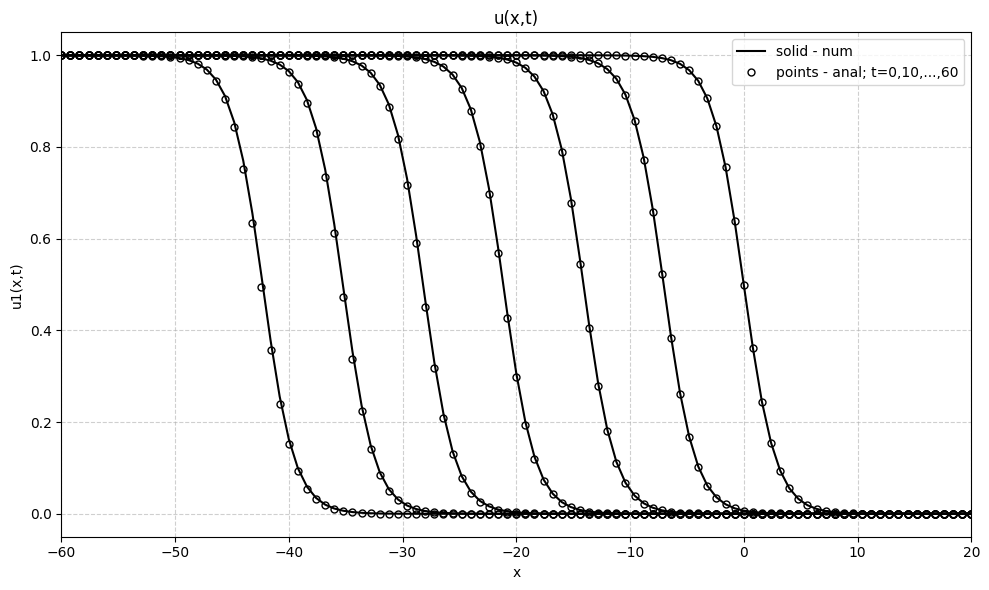

In [36]:

# ==========================================
# 3. Main Program
# ==========================================
# Level of output (1 = Plot only, 2 = Print table and plot)
ip = 2

# Alternative boundary conditions
ncase = 1

# Parameters
a = 1.0
D = 1.0
print(f"\n\n a = {a:5.2f}    D = {D:5.2f}\n")

# Grid (in x)
nx = 101
xl = -60.0
xu = 20.0
xg = np.linspace(xl, xu, nx)
dx = xg[1] - xg[0]

# Independent variable for ODE integration
nout = 7
tout = np.linspace(0, 60, nout)

# Initial condition (from analytical solution, t=0)
t0 = 0.0
u0 = ua_1(xg, t0, a, D)

# ODE integration using BDF (ideal for stiff systems like LSODES)
out = solve_ivp(
    fun=fhn_1,
    t_span=(tout[0], tout[-1]),
    y0=u0,
    t_eval=tout,
    args=(D, a, ncase, dx, xg),
    method='BDF'
)

# Extract numerical solution matrix
u_plot = out.y

# Calculate analytical solution matrix for comparison
ua_plot = np.zeros((nx, nout))
for it in range(nout):
    ua_plot[:, it] = ua_1(xg, tout[it], a, D)
"""
# Display numerical solution
if ip == 2:
    print(f"{'t':>5} {'x':>8} {'u(x,t)':>12} {'u_ex(x,t)':>12} {'u_err(x,t)':>13}")
    for it in range(nout):
        for ix in range(nx):
            t_val = tout[it]
            x_val = xg[ix]
            u_val = u_plot[ix, it]
            ua_val = ua_plot[ix, it]
            err = u_val - ua_val
            print(f"{t_val:5.1f} {x_val:8.2f} {u_val:12.5f} {ua_val:12.5f} {err:13.6f}")

"""

# Plot u numerical and analytical solutions
plt.figure(figsize=(10, 6))

for it in range(nout):
    # Plot numerical solutions as solid lines
    plt.plot(xg, u_plot[:, it], '-', color='black', linewidth=1.5,
             label='Numerical' if it == 0 else "")

    # Plot analytical solutions as points/circles
    plt.plot(xg, ua_plot[:, it], 'o', color='black', markerfacecolor='none',
             markersize=5, label='Analytical' if it == 0 else "")

plt.title('u(x,t)')
plt.xlabel('x')
plt.ylabel('u1(x,t)')
plt.xlim([xl, xu])
plt.legend(['solid - num', 'points - anal; t=0,10,...,60'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

###Results  Explained
Based on the complete set of images you provided (the math, the code, and the final graph), this represents the **successful numerical simulation and validation of a traveling wave** using the 1D FitzHugh-Nagumo (FHN) model.

Specifically, the final plot (`image_d17cf9.png`) is the visual proof that the Method of Lines (MOL) code works perfectly. Here is a breakdown of exactly what that graph is showing:

### 1. The Physics: A Traveling Wavefront

The graph shows a "wavefront" moving from left to right across the spatial domain.

* **The Y-axis ($u_1(x,t)$):** Represents the state of the system (e.g., electrical excitation in a nerve). It transitions smoothly from a high state (1.0) to a resting state (0.0).
* **The X-axis ($x$):** Represents physical space, moving from position -60 to 20.
* As time passes, the high state "invades" the low state, pushing the wave boundary to the right.

### 2. Time Snapshots (The Multiple Curves)

You aren't just looking at one line; you are looking at 7 distinct snapshots of the wave taken at 10-second intervals.

* The leftmost curve is the wave at time $t = 0$ (the initial condition).
* The next curve to the right is the wave at time $t = 10$.
* The rightmost curve is the wave at the final simulation time, $t = 60$.

Notice how the wave maintains its exact shape as it travels? That is the hallmark of a stable traveling wave in a reaction-diffusion system.

### 3. The Validation: Numerical vs. Analytical

The most important part of this plot is the legend in the top right corner:

* **Solid lines (`solid - num`):** This is the output calculated by the R ODE solver using the numerical Method of Lines approximations.
* **Open circles (`points - anal`):** These are the exact, true mathematical values calculated using the precise analytical traveling wave equation (Equation 4.2a from your first image).

**The Significance:** Because every single open circle lands perfectly on top of the solid black lines, it proves that your numerical simulation is incredibly accurate. It successfully calculated the complex reaction and diffusion physics over 60 seconds without drifting, distorting, or losing the shape of the wave.

###Incontinous Initial condition



 a =  1.00    D =  1.00



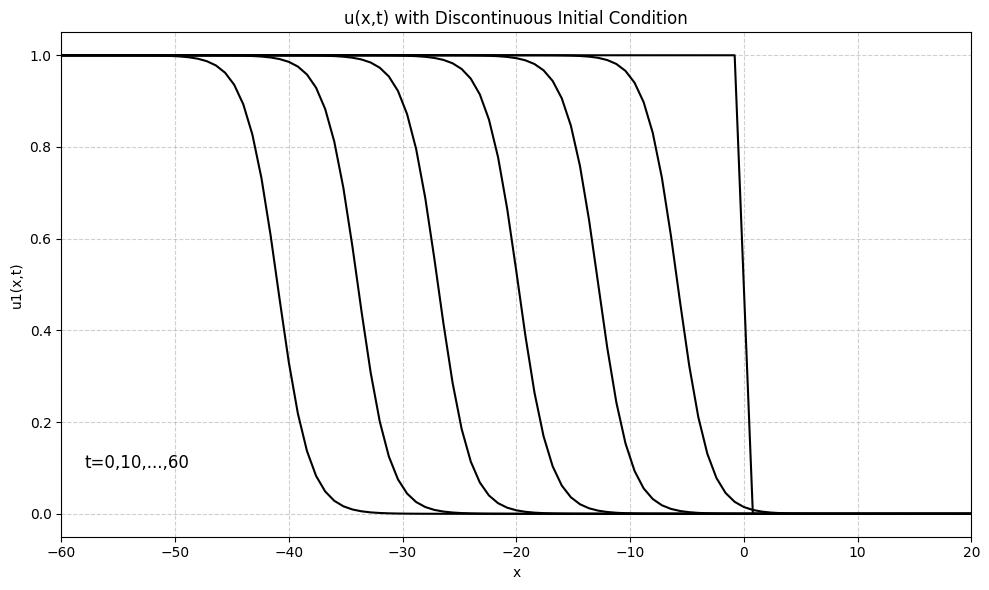

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==========================================
# 1. ODE Routine (fhn_1)
# ==========================================
def fhn_1(t, u, D, a, ncase, dx, xg):
    """Computes the time derivative vector for the FHN equation."""
    nx = len(u)
    ut = np.zeros(nx)
    uxx = np.zeros(nx)

    # Second spatial derivative for interior points
    uxx[1:-1] = (u[2:] - 2 * u[1:-1] + u[:-2]) / (dx**2)

    if ncase == 2:
        # Constant Dirichlet BCs at x = 0, 1 (Boundaries are fixed)
        ut[1:-1] = D * uxx[1:-1] - u[1:-1] * (1 - u[1:-1]) * (a - u[1:-1])
        ut[0] = 0.0
        ut[-1] = 0.0

    return ut

# ==========================================
# 2. Main Program: Discontinuous Initial Condition
# ==========================================
# Level of output (1 = plotted only, 2 = numerical and plotted)
ip = 2

# Select boundary condition case
ncase = 2 # Constant Dirichlet BCs

# Parameters
a = 1.0
D = 1.0
print(f"\n\n a = {a:5.2f}    D = {D:5.2f}\n")

# Grid (in x)
nx = 101
xl = -60.0
xu = 20.0
xg = np.linspace(xl, xu, nx)
dx = xg[1] - xg[0]

# Independent variable for ODE integration
nout = 7
tout = np.linspace(0, 60, nout)

# ==========================================
# THE KEY DIFFERENCE: Discontinuous Initial Condition (Unit Step)
# ==========================================
u0 = np.zeros(nx)

# Note: Python is 0-indexed. Index 76 in R corresponds to index 75 in Python.
# xg[75] corresponds exactly to x = 0.0
for i in range(nx):
    if i < 75:
        u0[i] = 1.0
    elif i == 75:
        u0[i] = 0.5
    elif i > 75:
        u0[i] = 0.0

# ODE integration using BDF (crucial for discontinuous/stiff initial conditions)
out = solve_ivp(
    fun=fhn_1,
    t_span=(tout[0], tout[-1]),
    y0=u0,
    t_eval=tout,
    args=(D, a, ncase, dx, xg),
    method='BDF'
)

# Extract numerical solution matrix
u_plot = out.y
"""
# Display numerical solution table
if ip == 2:
    print(f"{'t':>5} {'x':>8} {'u(x,t)':>12}")
    for it in range(nout):
        for ix in range(nx):
            print(f"{tout[it]:5.1f} {xg[ix]:8.2f} {u_plot[ix, it]:12.5f}")
"""
# Plot numerical solution
plt.figure(figsize=(10, 6))

# Plot the different time steps
for it in range(nout):
    plt.plot(xg, u_plot[:, it], '-', color='black', linewidth=1.5)

plt.title('u(x,t) with Discontinuous Initial Condition')
plt.xlabel('x')
plt.ylabel('u1(x,t)')
plt.xlim([xl, xu])
plt.text(xl + 2, 0.1, 't=0,10,...,60', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Solving ODEs for all 5 cases. This may take a few seconds...


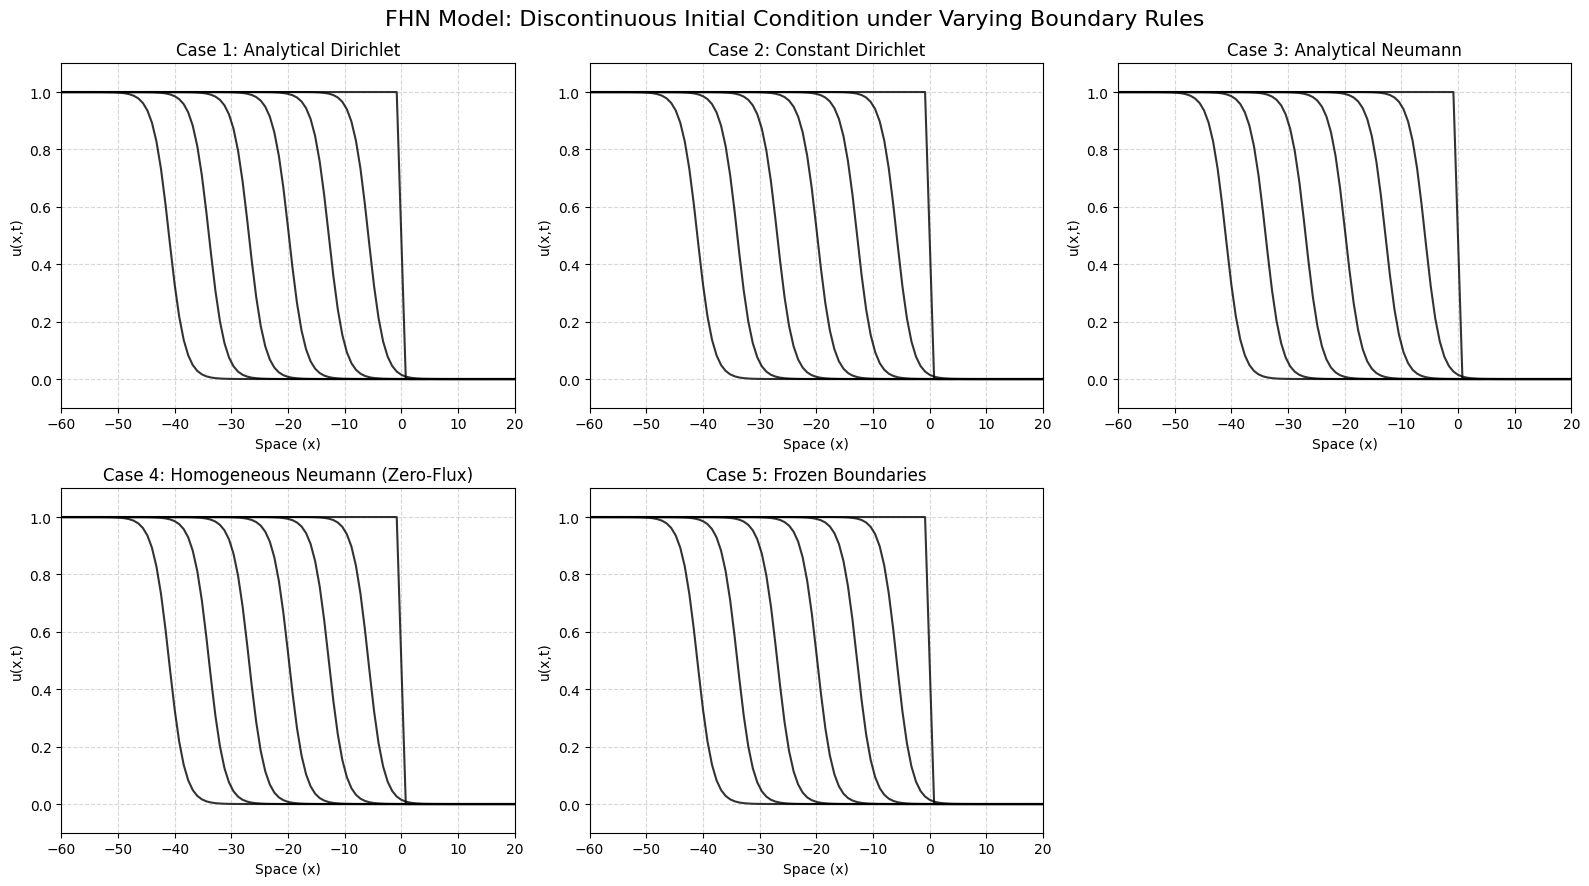

Simulation complete!


In [38]:


# ==========================================
# 1. Analytical Helper Functions (Required for Cases 1 & 3)
# ==========================================
def uxa_1(x, t, a, D):
    """Spatial derivative of the analytical solution (Eq 4.2b)"""
    term = x / np.sqrt(2 * D) + (a - 0.5) * t
    term = np.clip(term, -500, 500) # Prevent overflow
    e_term = np.exp(term)
    return -e_term * (1.0 / np.sqrt(2 * D)) / (1.0 + e_term)**2

def uta_1(x, t, a, D):
    """Time derivative of the analytical solution"""
    term = x / np.sqrt(2 * D) + (a - 0.5) * t
    term = np.clip(term, -500, 500) # Prevent overflow
    e_term = np.exp(term)
    return -e_term * (a - 0.5) / (1.0 + e_term)**2

# ==========================================
# 2. The Universal ODE Routine
# ==========================================
def fhn_1(t, u, D, a, ncase, dx, xg):
    """Computes the time derivative vector for the FHN equation"""
    nx = len(u)
    ut = np.zeros(nx)
    uxx = np.zeros(nx)

    # Apply spatial Boundary Conditions for Neumann cases
    if ncase == 3: # Analytical Neumann BCs
        ux_L = uxa_1(xg[0], t, a, D)
        ux_R = uxa_1(xg[-1], t, a, D)
        u_ghost_L = u[1] - 2 * dx * ux_L
        u_ghost_R = u[-2] + 2 * dx * ux_R
        uxx[0] = (u[1] - 2 * u[0] + u_ghost_L) / (dx**2)
        uxx[-1] = (u_ghost_R - 2 * u[-1] + u[-2]) / (dx**2)

    elif ncase == 4: # Homogeneous Neumann BCs
        uxx[0] = 2 * (u[1] - u[0]) / (dx**2)
        uxx[-1] = 2 * (u[-2] - u[-1]) / (dx**2)

    # Spatial derivative for interior points
    uxx[1:-1] = (u[2:] - 2 * u[1:-1] + u[:-2]) / (dx**2)

    # Calculate Time Derivatives
    if ncase in [1, 2]:
        # PDE applied to interior points only
        ut[1:-1] = D * uxx[1:-1] - u[1:-1] * (1 - u[1:-1]) * (a - u[1:-1])

        if ncase == 1:
            # Analytical Dirichlet: Force bounds to follow exact time derivative
            ut[0] = uta_1(xg[0], t, a, D)
            ut[-1] = uta_1(xg[-1], t, a, D)
        elif ncase == 2:
            # Constant Dirichlet: Bounds do not change
            ut[0] = 0.0
            ut[-1] = 0.0

    elif ncase in [3, 4, 5]:
        # PDE applied to all points
        ut = D * uxx - u * (1 - u) * (a - u)

    return ut

# ==========================================
# 3. Main Program: Testing All Cases with a Cliff
# ==========================================
# Parameters
a = 1.0
D = 1.0
nx = 101
xg = np.linspace(-60, 20, nx)
dx = xg[1] - xg[0]

# Time array (0 to 60 seconds, 7 snapshots)
tout = np.linspace(0, 60, 7)

# Create the Discontinuous Initial Condition (Unit Step)
u0 = np.zeros(nx)
u0[xg < 0] = 1.0
u0[xg == 0] = 0.5
u0[xg > 0] = 0.0

cases = {
    1: "Analytical Dirichlet",
    2: "Constant Dirichlet",
    3: "Analytical Neumann",
    4: "Homogeneous Neumann (Zero-Flux)",
    5: "Frozen Boundaries"
}

# Set up a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

print("Solving ODEs for all 5 cases. This may take a few seconds...")

for i, (ncase, title) in enumerate(cases.items()):

    # Run the ODE solver for this specific case
    out = solve_ivp(
        fun=fhn_1,
        t_span=(tout[0], tout[-1]),
        y0=u0,
        t_eval=tout,
        args=(D, a, ncase, dx, xg),
        method='BDF'
    )

    u_plot = out.y
    ax = axes[i]

    # Plot the 7 time snapshots
    for it in range(len(tout)):
        ax.plot(xg, u_plot[:, it], '-', color='black', alpha=0.8)

    ax.set_title(f"Case {ncase}: {title}")
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(-60, 20)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlabel("Space (x)")
    ax.set_ylabel("u(x,t)")

# Hide the 6th unused subplot
axes[5].axis('off')

plt.suptitle("FHN Model: Discontinuous Initial Condition under Varying Boundary Rules", fontsize=16)
plt.tight_layout()
plt.show()
print("Simulation complete!")

###Testing other ranges for x

Solving ODEs for all 5 cases. This may take a few seconds...


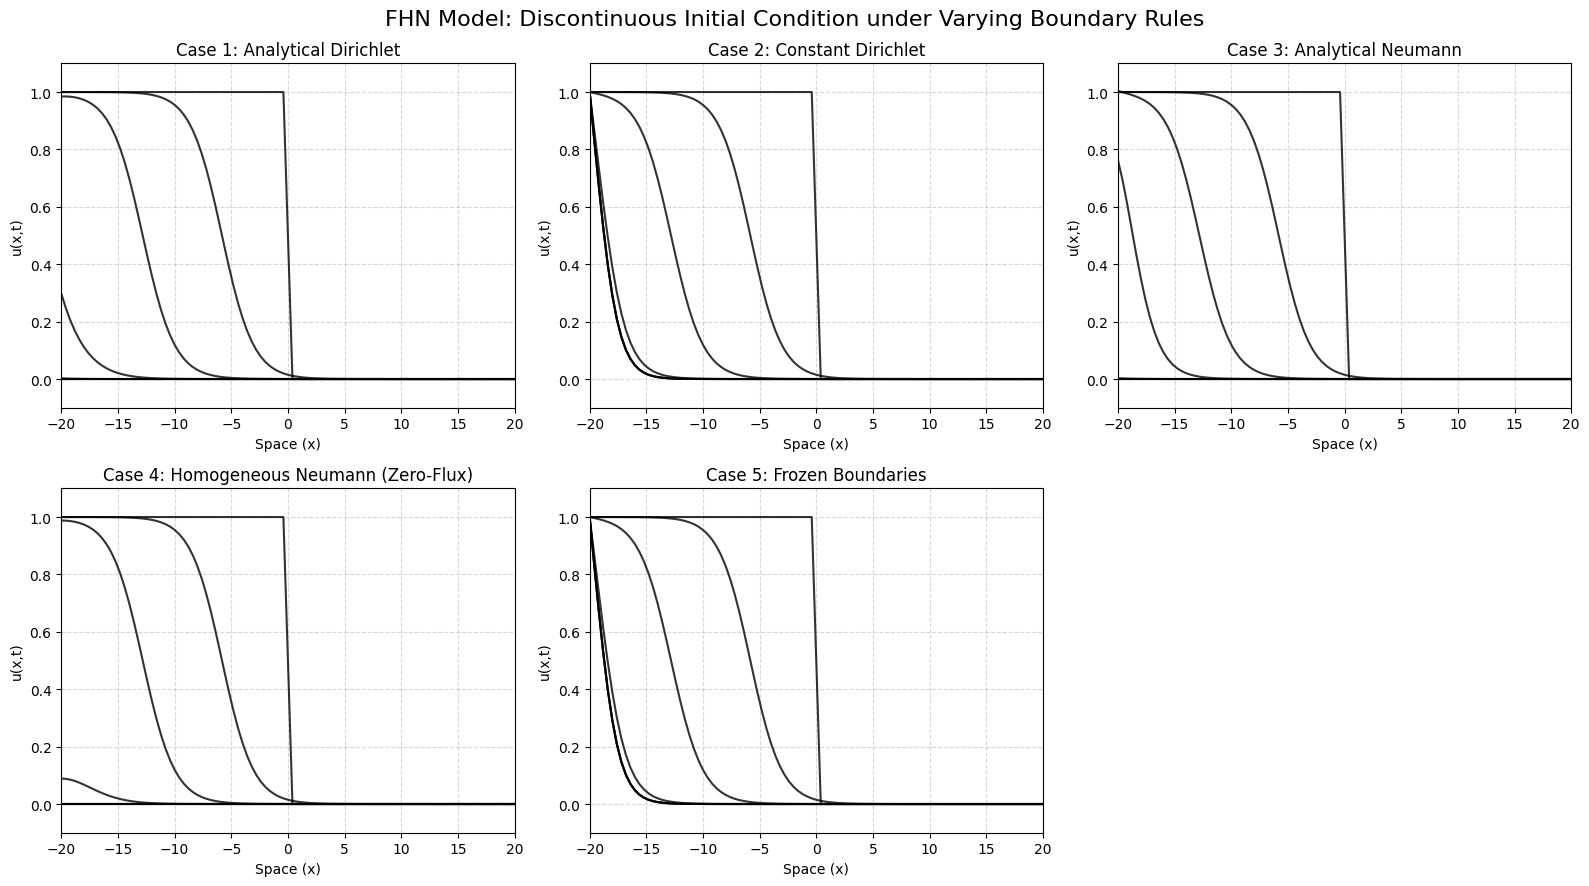

Simulation complete!


In [39]:


# ==========================================
# 1. Analytical Helper Functions (Required for Cases 1 & 3)
# ==========================================
def uxa_1(x, t, a, D):
    """Spatial derivative of the analytical solution (Eq 4.2b)"""
    term = x / np.sqrt(2 * D) + (a - 0.5) * t
    term = np.clip(term, -500, 500) # Prevent overflow
    e_term = np.exp(term)
    return -e_term * (1.0 / np.sqrt(2 * D)) / (1.0 + e_term)**2

def uta_1(x, t, a, D):
    """Time derivative of the analytical solution"""
    term = x / np.sqrt(2 * D) + (a - 0.5) * t
    term = np.clip(term, -500, 500) # Prevent overflow
    e_term = np.exp(term)
    return -e_term * (a - 0.5) / (1.0 + e_term)**2

# ==========================================
# 2. The Universal ODE Routine
# ==========================================
def fhn_1(t, u, D, a, ncase, dx, xg):
    """Computes the time derivative vector for the FHN equation"""
    nx = len(u)
    ut = np.zeros(nx)
    uxx = np.zeros(nx)

    # Apply spatial Boundary Conditions for Neumann cases
    if ncase == 3: # Analytical Neumann BCs
        ux_L = uxa_1(xg[0], t, a, D)
        ux_R = uxa_1(xg[-1], t, a, D)
        u_ghost_L = u[1] - 2 * dx * ux_L
        u_ghost_R = u[-2] + 2 * dx * ux_R
        uxx[0] = (u[1] - 2 * u[0] + u_ghost_L) / (dx**2)
        uxx[-1] = (u_ghost_R - 2 * u[-1] + u[-2]) / (dx**2)

    elif ncase == 4: # Homogeneous Neumann BCs
        uxx[0] = 2 * (u[1] - u[0]) / (dx**2)
        uxx[-1] = 2 * (u[-2] - u[-1]) / (dx**2)

    # Spatial derivative for interior points
    uxx[1:-1] = (u[2:] - 2 * u[1:-1] + u[:-2]) / (dx**2)

    # Calculate Time Derivatives
    if ncase in [1, 2]:
        # PDE applied to interior points only
        ut[1:-1] = D * uxx[1:-1] - u[1:-1] * (1 - u[1:-1]) * (a - u[1:-1])

        if ncase == 1:
            # Analytical Dirichlet: Force bounds to follow exact time derivative
            ut[0] = uta_1(xg[0], t, a, D)
            ut[-1] = uta_1(xg[-1], t, a, D)
        elif ncase == 2:
            # Constant Dirichlet: Bounds do not change
            ut[0] = 0.0
            ut[-1] = 0.0

    elif ncase in [3, 4, 5]:
        # PDE applied to all points
        ut = D * uxx - u * (1 - u) * (a - u)

    return ut

# ==========================================
# 3. Main Program: Testing All Cases with a Cliff
# ==========================================
# Parameters
a = 1.0
D = 1.0
nx = 101

# THE TWEAK: Shrink the left boundary from -60 to -20
xl=-20
xu=20
xg = np.linspace(xl, xu, nx)
dx = xg[1] - xg[0]

# Time array (0 to 60 seconds)
tout = np.linspace(0, 60, 7)
# Create the Discontinuous Initial Condition (Unit Step)
u0 = np.zeros(nx)
u0[xg < 0] = 1.0
u0[xg == 0] = 0.5
u0[xg > 0] = 0.0

cases = {
    1: "Analytical Dirichlet",
    2: "Constant Dirichlet",
    3: "Analytical Neumann",
    4: "Homogeneous Neumann (Zero-Flux)",
    5: "Frozen Boundaries"
}

# Set up a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

print("Solving ODEs for all 5 cases. This may take a few seconds...")

for i, (ncase, title) in enumerate(cases.items()):

    # Run the ODE solver for this specific case
    out = solve_ivp(
        fun=fhn_1,
        t_span=(tout[0], tout[-1]),
        y0=u0,
        t_eval=tout,
        args=(D, a, ncase, dx, xg),
        method='BDF'
    )

    u_plot = out.y
    ax = axes[i]

    # Plot the 7 time snapshots
    for it in range(len(tout)):
        ax.plot(xg, u_plot[:, it], '-', color='black', alpha=0.8)

    ax.set_title(f"Case {ncase}: {title}")
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(xl, xu)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlabel("Space (x)")
    ax.set_ylabel("u(x,t)")

# Hide the 6th unused subplot
axes[5].axis('off')

plt.suptitle("FHN Model: Discontinuous Initial Condition under Varying Boundary Rules", fontsize=16)
plt.tight_layout()
plt.show()
print("Simulation complete!")

# Fundamentals of the Fully Discrete Finite Difference Method (FDM) Method (Using the FHN Model)

**FTCS** stands for **Forward-Time Central-Space**. It is a fundamental explicit finite difference method used to solve time-dependent Partial Differential Equations (PDEs).

While often taught using simple heat diffusion, it can easily be applied to non-linear reaction-diffusion systems like the simplified 1D FitzHugh-Nagumo (FHN) model. Here is a complete breakdown of how FTCS discretizes and solves this specific equation.

---

## 1. The Mathematical Problem
The simplified 1D FHN model tracks a single variable (like voltage) propagating through a medium:

$$\frac{\partial u}{\partial t} = D \frac{\partial^2 u}{\partial x^2} - u(1 - u)(a - u)$$

Where:
* $u(x,t)$ is the state variable.
* $D$ is the diffusion coefficient.
* $a$ is the threshold parameter.
* $D\frac{\partial^2 u}{\partial x^2}$ is the spatial diffusion term.
* $-u(1-u)(a-u)$ is the non-linear reaction term.

## 2. Discretizing Space and Time
Computers cannot solve continuous functions directly. We must chop space and time into a discrete grid:
* **Space ($x$):** Divided into discrete nodes separated by a constant distance $\Delta x$. We use the subscript $i$ to denote spatial position (e.g., $x_i$).
* **Time ($t$):** Divided into discrete steps separated by a constant duration $\Delta t$. We use the superscript $n$ to denote the time step (e.g., $t^n$).

Therefore, the exact value of our wave at a specific point in space and time is written as: **$u_i^n$**

## 3. The Core Approximations
The name "FTCS" dictates exactly how we approximate the derivatives.

### A. Forward-Time (FT)
We approximate the time derivative ($\frac{\partial u}{\partial t}$) using a **Forward Euler** difference. We look at the difference between the *current* time step ($n$) and the *future* time step ($n+1$):

$$\frac{\partial u}{\partial t} \approx \frac{u_i^{n+1} - u_i^n}{\Delta t}$$

### B. Central-Space (CS)
We approximate the spatial diffusion derivative ($\frac{\partial^2 u}{\partial x^2}$) using a **Central** difference. We look at the node's immediate neighbors to the left ($i-1$) and right ($i+1$) exactly as they are at the *current* time step ($n$):

$$\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2}$$

## 4. Constructing the FTCS Equation
We substitute these approximations back into the continuous FHN equation. Note that the non-linear reaction term is simply evaluated at the current, known state ($u_i^n$):

$$\frac{u_i^{n+1} - u_i^n}{\Delta t} = D \left( \frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2} \right) - u_i^n(1 - u_i^n)(a - u_i^n)$$

Because the goal is to predict the future, we algebraically isolate the future term ($u_i^{n+1}$) on the left side:

$$u_i^{n+1} = u_i^n + \frac{D \Delta t}{\Delta x^2} \left( u_{i+1}^n - 2u_i^n + u_{i-1}^n \right) - \Delta t \big[ u_i^n(1 - u_i^n)(a - u_i^n) \big]$$

To make the math cleaner and track stability, we bundle the diffusion constants into a dimensionless number called the **Fourier Number** (or grid parameter), denoted as $r$:

$$r = \frac{D \Delta t}{\Delta x^2}$$

This gives us the final, highly elegant FTCS algebraic update equation:

$$u_i^{n+1} = r u_{i+1}^n + (1 - 2r)u_i^n + r u_{i-1}^n - \Delta t \big[ u_i^n(1 - u_i^n)(a - u_i^n) \big]$$

---

## 5. How the Algorithm Works in Practice
This equation reveals the simplicity of the explicit FTCS method. To find the exact state of a node in the next time step, you only need to know its current state and the current state of its two immediate neighbors.

Here is the loop a computer runs:
1. **Initialize:** Define the starting values $u_i^0$ for all spatial nodes at $t=0$.
2. **Apply Boundaries:** Set the values at the far left and right edges (e.g., using ghost nodes for Zero-Flux).
3. **Time Loop:** Begin stepping forward by $\Delta t$.
4. **Space Loop:** At each time step, loop through every internal node $i$. Apply the FTCS equation to calculate $u_i^{n+1}$ using only the known values from the current array $u^n$.
5. **Overwrite and Repeat:** Once the entire future array $u^{n+1}$ is calculated, overwrite $u^n$ with it, and repeat the loop.

---

## 6. The Fatal Flaw: Stability Limits
Because FTCS is an **explicit** method (it calculates the future blindly without cross-checking for physical constraints), it is highly prone to numerical instability.

Look at the middle diffusion term of the FTCS equation: **$(1 - 2r)u_i^n$**

If $r > 0.5$, the coefficient $(1 - 2r)$ becomes negative. This physically implies that an excited, high-value node will cause itself to violently drop into a negative state in the very next instant. This triggers wild mathematical oscillations that instantly explode to infinity.

Therefore, you must strictly obey the Courant-Friedrichs-Lewy (CFL) stability criterion for the diffusion term:

$$r \le \frac{1}{2} \implies \Delta t \le \frac{\Delta x^2}{2D}$$

*Note: In reaction-diffusion systems like FHN, the non-linear reaction term can sometimes impose an even stricter limit on $\Delta t$ to prevent the cubic multiplier from blowing up, but the diffusion CFL limit is almost always the primary bottleneck that forces FTCS to take thousands of tiny time steps.*

##Fully Discrete Finite Difference Method (FDM) VS Method of Lines(MOL)

Starting MOL (Implicit BDF)...
MOL finished in: 0.0137 seconds (Took 19 time steps)

Starting Fully Discrete FDM (Explicit FTCS)...
FTCS finished in: 0.0039 seconds (Took 124 time steps)


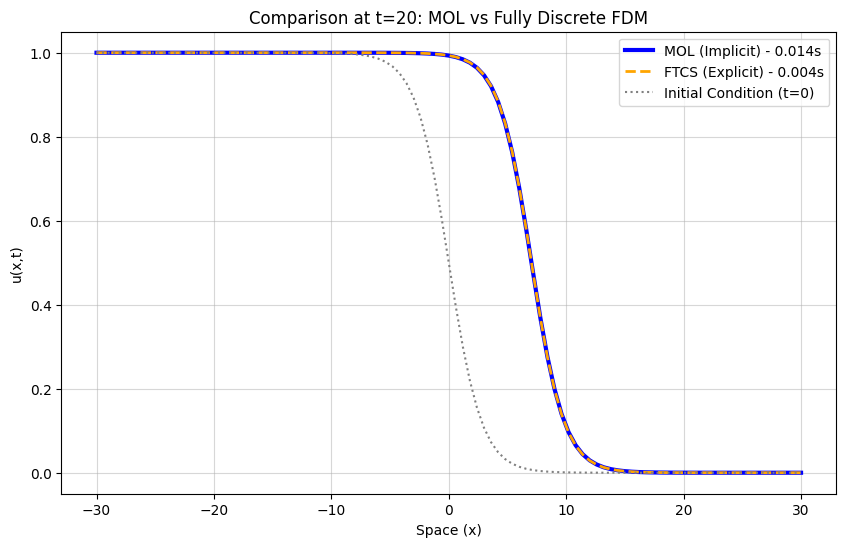

In [40]:

import time
# ==========================================
# 1. Setup & Parameters
# ==========================================
a = 0.25
D = 1.0
nx = 101
xg = np.linspace(-30, 30, nx)
dx = xg[1] - xg[0]

# Simulation time
t_final = 20.0

# Initial Condition (Traveling wave)
u0 = 1.0 / (1.0 + np.exp(xg / np.sqrt(2 * D)))

# ==========================================
# 2. Method 1: MOL with Implicit BDF
# ==========================================
def fhn_mol(t, u):
    uxx = np.zeros(nx)
    uxx[1:-1] = (u[2:] - 2 * u[1:-1] + u[:-2]) / (dx**2)

    # Zero-flux Neumann boundaries
    uxx[0] = 2 * (u[1] - u[0]) / (dx**2)
    uxx[-1] = 2 * (u[-2] - u[-1]) / (dx**2)

    return D * uxx - u * (1 - u) * (a - u)

print("Starting MOL (Implicit BDF)...")
start_time = time.time()

mol_sol = solve_ivp(
    fun=fhn_mol, t_span=(0, t_final), y0=u0, method='BDF'
)

mol_time = time.time() - start_time
u_mol_final = mol_sol.y[:, -1]
print(f"MOL finished in: {mol_time:.4f} seconds (Took {len(mol_sol.t)} time steps)")

# ==========================================
# 3. Method 2: Fully Discrete FDM (Explicit FTCS)
# ==========================================
print("\nStarting Fully Discrete FDM (Explicit FTCS)...")
start_time = time.time()

# STABILITY LIMIT: Explicit methods explode if dt is too large!
# The CFL condition for diffusion requires: dt <= (dx^2) / (2*D)
dt_max = (dx**2) / (2.0 * D)
dt = dt_max * 0.9  # Use 90% of max allowed step for safety
num_steps = int(np.ceil(t_final / dt))

u_ftcs = u0.copy()
uxx = np.zeros(nx)

for n in range(num_steps):
    # Calculate spatial derivative
    uxx[1:-1] = (u_ftcs[2:] - 2 * u_ftcs[1:-1] + u_ftcs[:-2]) / (dx**2)
    uxx[0] = 2 * (u_ftcs[1] - u_ftcs[0]) / (dx**2)   # Left boundary
    uxx[-1] = 2 * (u_ftcs[-2] - u_ftcs[-1]) / (dx**2) # Right boundary

    # Calculate reaction
    reaction = u_ftcs * (1 - u_ftcs) * (a - u_ftcs)

    # Step forward in time explicitly
    u_ftcs = u_ftcs + dt * (D * uxx - reaction)

ftcs_time = time.time() - start_time
print(f"FTCS finished in: {ftcs_time:.4f} seconds (Took {num_steps} time steps)")

# ==========================================
# 4. Plot Comparison
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(xg, u_mol_final, '-', linewidth=3, label=f'MOL (Implicit) - {mol_time:.3f}s', color='blue')
plt.plot(xg, u_ftcs, '--', linewidth=2, label=f'FTCS (Explicit) - {ftcs_time:.3f}s', color='orange')
plt.plot(xg, u0, ':', color='grey', label='Initial Condition (t=0)')

plt.title('Comparison at t=20: MOL vs Fully Discrete FDM')
plt.xlabel('Space (x)')
plt.ylabel('u(x,t)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# Fundamentals of Operator Splitting via the Strang Splitting Algorithm

**Operator Splitting** (specifically **Strang Splitting**) is an advanced numerical technique designed for multi-physics partial differential equations (PDEs), such as reaction-diffusion equations.

Instead of forcing a single, rigid numerical solver to integrate a complex equation simultaneously, Operator Splitting breaks the PDE apart into its individual physical sub-problems. It solves each mechanism independently using the most optimal numerical tool for that specific task.

---

## 1. The Core Philosophy: "Divide and Conquer"
The 1D FitzHugh-Nagumo (FHN) equation features two completely different mathematical operators:

$$\frac{\partial u}{\partial t} = \underbrace{D \frac{\partial^2 u}{\partial x^2}}_{\text{Linear Diffusion}} + \underbrace{\vphantom{D \frac{\partial^2 u}{\partial x^2}}-u(1 - u)(a - u)}_{\text{Non-linear Reaction}}$$

1. **The Diffusion Operator:** A linear spatial term that couples nodes together. It causes numerical stiffness, requiring an *implicit* solver to prevent calculations from exploding.
2. **The Reaction Operator:** A non-linear cubic polynomial. It acts locally on individual points without any spatial dependencies, requiring a *highly accurate non-linear* solver.

Strang Splitting decouples these physics over a macro time step $\Delta t$ by alternating between them in a specific "sandwich" order.

---

## 2. The Strang Splitting Algorithm Step-by-Step
To advance the entire system from time $t^n$ to $t^{n+1}$ across a time step $\Delta t$, the algorithm executes three distinct steps in sequence:



### Step 1: The First Reaction Half-Step ($\Delta t / 2$)
We completely freeze spatial diffusion ($D=0$). The system is treated as if every single grid point is an isolated chemical beaker. We advance the state $u^n$ forward by a half time step ($\frac{\Delta t}{2}$) using **only** the non-linear reaction math:

$$\frac{d u}{d t} = -u(1 - u)(a - u) \quad \text{for } t \in \left[0, \frac{\Delta t}{2}\right]$$

* **The Code Implementation (`reaction_rk4`):** Because there are no spatial derivatives, all $N$ grid points are solved simultaneously using an explicit **4th-order Runge-Kutta (RK4)** method. It evaluates four unique slope estimates ($k_1, k_2, k_3, k_4$) to achieve 4th-order temporal accuracy across this small interval, yielding an intermediate state $u^*$.

### Step 2: The Full Diffusion Step ($\Delta t$)
We take the intermediate state $u^*$ and completely freeze the chemical reaction. We let the wave diffuse across the grid for a full time step ($\Delta t$) by solving a pure diffusion equation:

$$\frac{\partial u}{\partial t} = D \frac{\partial^2 u}{\partial x^2} \quad \text{for } t \in [0, \Delta t]$$

* **The Code Implementation (`solve_diffusion`):** Space is discretized using a standard central finite difference approximation ($u_{xx}$). To easily handle the numerical stiffness caused by the grid spacing ($\Delta x^2$), this linear system is handed directly to SciPy's implicit **Backward Differentiation Formula (BDF)** solver. It computes a highly stable spatial smoothing over the full $\Delta t$, outputting a second intermediate state $u^{**}$.

### Step 3: The Second Reaction Half-Step ($\Delta t / 2$)
We freeze spatial diffusion once again. We take the smoothed state $u^{**}$ and let the chemical reaction execute for the remaining half time step ($\frac{\Delta t}{2}$):

$$\frac{d u}{d t} = -u(1 - u)(a - u) \quad \text{for } t \in \left[\frac{\Delta t}{2}, \Delta t\right]$$

* **The Code Implementation:** The explicit RK4 solver processes the array one final time, advancing the system to its final, fully integrated state at $t^{n+1}$.

---

## 3. Why the "Sandwich" Order Matters: Minimizing Error
If you simply solved a full step of reaction followed by a full step of diffusion (called *Godunov Splitting*), you would introduce a significant first-order mathematical error $\mathcal{O}(\Delta t)$ because the two physical processes actually occur simultaneously in nature.

By splitting the reaction into two symmetrical half-steps wrapped around a full diffusion step, the mathematical errors introduced by freezing the physics in Step 1 are exactly canceled out by the physics in Step 3. This symmetry elevates Strang Splitting to a **second-order accurate** method $\mathcal{O}(\Delta t^2)$, making it exceptionally clean and precise.

---

## 4. Summary of Practical Advantages
* **Immunity to the CFL Constraint:** Because the stiff diffusion operator is processed using an implicit BDF method, the simulation is not bound by the tight explicit speed limits ($\Delta t \le \frac{\Delta x^2}{2D}$). You can safely use massive macro time steps (like `dt = 0.5`), making the simulation compute incredibly fast.
* **Vectorized Processing:** The non-linear reaction step does not require looping through individual grid elements or constructing giant multi-variable matrices. It is calculated across the entire NumPy array instantaneously using efficient, low-level C-libraries.

Starting Strang Splitting (dt = 0.5)...
Simulation Complete!


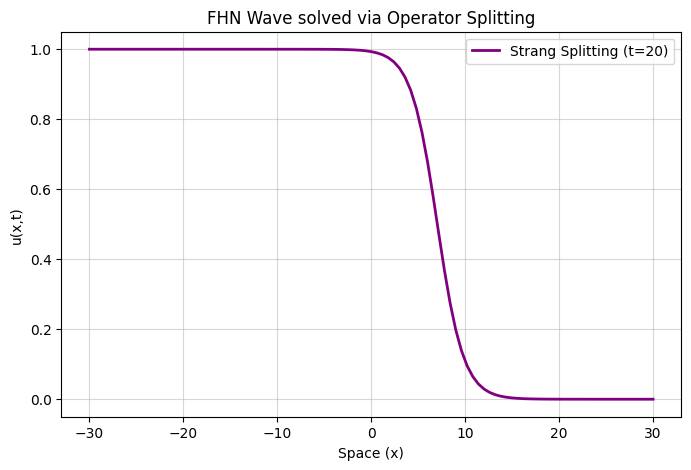

In [41]:
# ==========================================
# 1. The Reaction Solver (Explicit RK4)
# ==========================================
# This strictly calculates: du/dt = -u(1-u)(a-u)
# Notice there is NO spatial dx or u_xx here. Every node is independent.
def reaction_rk4(u, a, dt):
    """Solves the reaction step using a standard 4th-order Runge-Kutta"""
    def f(u_val):
        return -u_val * (1 - u_val) * (a - u_val)

    k1 = f(u)
    k2 = f(u + 0.5 * dt * k1)
    k3 = f(u + 0.5 * dt * k2)
    k4 = f(u + dt * k3)

    return u + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

# ==========================================
# 2. The Diffusion Solver (Implicit BDF)
# ==========================================
# This strictly calculates: du/dt = D * u_xx
# Notice there is NO reaction term here.
def diffusion_ode(t, u, D, dx):
    """The spatial derivative function for the ODE solver"""
    uxx = np.zeros(len(u))
    uxx[1:-1] = (u[2:] - 2 * u[1:-1] + u[:-2]) / (dx**2)

    # Zero-flux Neumann boundaries
    uxx[0] = 2 * (u[1] - u[0]) / (dx**2)
    uxx[-1] = 2 * (u[-2] - u[-1]) / (dx**2)

    return D * uxx

def solve_diffusion(u_initial, D, dx, dt):
    """Wraps scipy's BDF solver to handle exactly one time step of diffusion"""
    sol = solve_ivp(
        fun=diffusion_ode,
        t_span=(0, dt),
        y0=u_initial,
        args=(D, dx),
        method='BDF'
    )
    # Return only the final state after the dt step
    return sol.y[:, -1]

# ==========================================
# 3. The Main Strang Splitting Loop
# ==========================================
# Parameters
a = 0.25
D = 1.0
nx = 101
xg = np.linspace(-30, 30, nx)
dx = xg[1] - xg[0]

dt = 0.5            # We can use a massive time step thanks to splitting!
t_final = 20.0
num_steps = int(t_final / dt)

# Initial Condition
u = 1.0 / (1.0 + np.exp(xg / np.sqrt(2 * D)))

print(f"Starting Strang Splitting (dt = {dt})...")

# The Time Loop
for n in range(num_steps):

    # STEP 1: Half-step of Reaction (dt/2)
    u_star = reaction_rk4(u, a, dt / 2.0)

    # STEP 2: Full-step of Diffusion (dt)
    u_star_star = solve_diffusion(u_star, D, dx, dt)

    # STEP 3: Half-step of Reaction (dt/2)
    u = reaction_rk4(u_star_star, a, dt / 2.0)

print("Simulation Complete!")

# ==========================================
# 4. Plot the Result
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(xg, u, '-', linewidth=2, color='purple', label='Strang Splitting (t=20)')
plt.title('FHN Wave solved via Operator Splitting')
plt.xlabel('Space (x)')
plt.ylabel('u(x,t)')
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

# 5. Comprehensive Analysis & Side-by-Side Comparison

This section performs a complete benchmarking and error analysis across the three numerical techniques introduced above:
1. **Method of Lines (MOL)** with an implicit Adaptive BDF solver.
2. **Fully Discrete Finite Difference Method (FTCS)** with a conditionally stable explicit step.
3. **Operator Splitting (Strang Splitting)** using explicit RK4 for reaction and implicit BDF for pure diffusion.

We compare them against the exact analytical traveling wave solution at $t=20$ to assess accuracy, efficiency (execution time), and total time steps taken.

          Method  Execution Time (s)  Total Steps  Max Abs Error  RMSE Error
 Method of Lines            0.014431           19       0.005171    0.001154
   Explicit FTCS            0.003285          124       0.010715    0.002511
Strang Splitting            0.133287           40       0.007813    0.001749


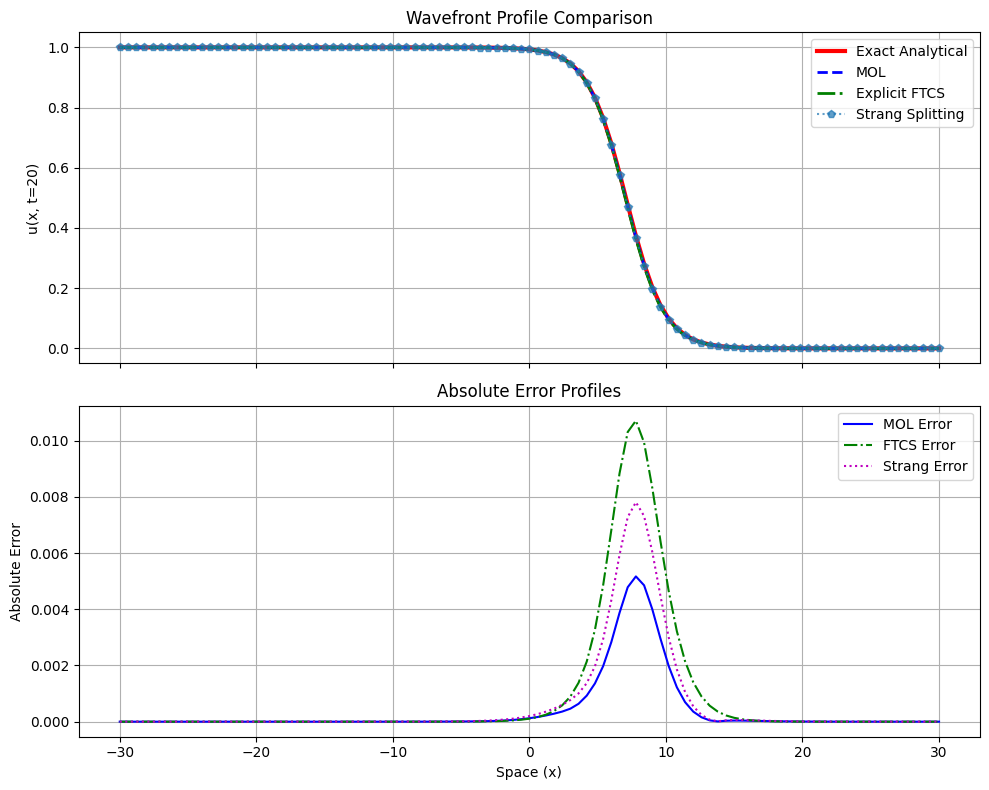

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import time

# Universal Setup
a = 0.25
D = 1.0
nx = 101
xg = np.linspace(-30, 30, nx)
dx = xg[1] - xg[0]
t_final = 20.0

def ua_exact(x, t, a, D):
    term = x / np.sqrt(2 * D) + (a - 0.5) * t
    term = np.clip(term, -500, 500)
    return 1.0 / (1.0 + np.exp(term))

u0 = ua_exact(xg, 0.0, a, D)
u_exact_final = ua_exact(xg, t_final, a, D)

# 1. Method of Lines (MOL)
def fhn_mol(t, u):
    uxx = np.zeros(nx)
    uxx[1:-1] = (u[2:] - 2 * u[1:-1] + u[:-2]) / (dx**2)
    uxx[0] = 2 * (u[1] - u[0]) / (dx**2)
    uxx[-1] = 2 * (u[-2] - u[-1]) / (dx**2)
    return D * uxx - u * (1 - u) * (a - u)

t_start = time.time()
sol_mol = solve_ivp(fun=fhn_mol, t_span=(0, t_final), y0=u0, method='BDF')
time_mol = time.time() - t_start
u_mol = sol_mol.y[:, -1]
steps_mol = len(sol_mol.t)

# 2. Explicit FTCS
t_start = time.time()
dt_ftcs = (dx**2) / (2.0 * D) * 0.9
num_steps_ftcs = int(np.ceil(t_final / dt_ftcs))
dt_ftcs_actual = t_final / num_steps_ftcs

u_ftcs = u0.copy()
uxx = np.zeros(nx)
for n in range(num_steps_ftcs):
    uxx[1:-1] = (u_ftcs[2:] - 2 * u_ftcs[1:-1] + u_ftcs[:-2]) / (dx**2)
    uxx[0] = 2 * (u_ftcs[1] - u_ftcs[0]) / (dx**2)
    uxx[-1] = 2 * (u_ftcs[-2] - u_ftcs[-1]) / (dx**2)
    reaction = u_ftcs * (1 - u_ftcs) * (a - u_ftcs)
    u_ftcs = u_ftcs + dt_ftcs_actual * (D * uxx - reaction)
time_ftcs = time.time() - t_start
steps_ftcs = num_steps_ftcs

# 3. Operator Splitting (Strang Splitting)
def reaction_rk4(u_val, dt_step):
    def f(u_tmp): return -u_tmp * (1 - u_tmp) * (a - u_tmp)
    k1 = f(u_val)
    k2 = f(u_val + 0.5 * dt_step * k1)
    k3 = f(u_val + 0.5 * dt_step * k2)
    k4 = f(u_val + dt_step * k3)
    return u_val + (dt_step / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def diffusion_ode(t, u_val):
    uxx = np.zeros(nx)
    uxx[1:-1] = (u_val[2:] - 2 * u_val[1:-1] + u_val[:-2]) / (dx**2)
    uxx[0] = 2 * (u_val[1] - u_val[0]) / (dx**2)
    uxx[-1] = 2 * (u_val[-2] - u_val[-1]) / (dx**2)
    return D * uxx

t_start = time.time()
dt_strang = 0.5
num_steps_strang = int(t_final / dt_strang)
u_strang = u0.copy()
for n in range(num_steps_strang):
    u_star = reaction_rk4(u_strang, dt_strang / 2.0)
    sol_diff = solve_ivp(fun=diffusion_ode, t_span=(0, dt_strang), y0=u_star, method='BDF')
    u_star_star = sol_diff.y[:, -1]
    u_strang = reaction_rk4(u_star_star, dt_strang / 2.0)
time_strang = time.time() - t_start
steps_strang = num_steps_strang

# Compute errors
err_mol_max = np.max(np.abs(u_mol - u_exact_final))
err_ftcs_max = np.max(np.abs(u_ftcs - u_exact_final))
err_strang_max = np.max(np.abs(u_strang - u_exact_final))

err_mol_rmse = np.sqrt(np.mean((u_mol - u_exact_final)**2))
err_ftcs_rmse = np.sqrt(np.mean((u_ftcs - u_exact_final)**2))
err_strang_rmse = np.sqrt(np.mean((u_strang - u_exact_final)**2))

# Build DataFrame table
df = pd.DataFrame({
    'Method': ['Method of Lines', 'Explicit FTCS', 'Strang Splitting'],
    'Execution Time (s)': [time_mol, time_ftcs, time_strang],
    'Total Steps': [steps_mol, steps_ftcs, steps_strang],
    'Max Abs Error': [err_mol_max, err_ftcs_max, err_strang_max],
    'RMSE Error': [err_mol_rmse, err_ftcs_rmse, err_strang_rmse]
})
print(df.to_string(index=False))
%matplotlib inline
# Plot side by side
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(xg, u_exact_final, 'r-', linewidth=3, label='Exact Analytical')
axes[0].plot(xg, u_mol, 'b--', linewidth=2, label='MOL')
axes[0].plot(xg, u_ftcs, 'g-.', linewidth=2, label='Explicit FTCS')
axes[0].plot(xg, u_strang, 'p:', label='Strang Splitting', alpha=0.7)
axes[0].set_ylabel('u(x, t=20)')
axes[0].set_title('Wavefront Profile Comparison')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(xg, np.abs(u_mol - u_exact_final), 'b-', label='MOL Error')
axes[1].plot(xg, np.abs(u_ftcs - u_exact_final), 'g-.', label='FTCS Error')
axes[1].plot(xg, np.abs(u_strang - u_exact_final), 'm:', label='Strang Error')
axes[1].set_ylabel('Absolute Error')
axes[1].set_xlabel('Space (x)')
axes[1].set_title('Absolute Error Profiles')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.savefig('fhn_notebook_comparison.png', dpi=300)
plt.show()


Modefying Strange splitting to improve performance

             Method  Execution Time (s)  Total Steps  Max Abs Error  RMSE Error
    Method of Lines            0.010238           19       0.005171    0.001154
      Explicit FTCS            0.001877          124       0.010715    0.002511
Strang (Matrix Exp)            0.011697           40       0.006065    0.001334


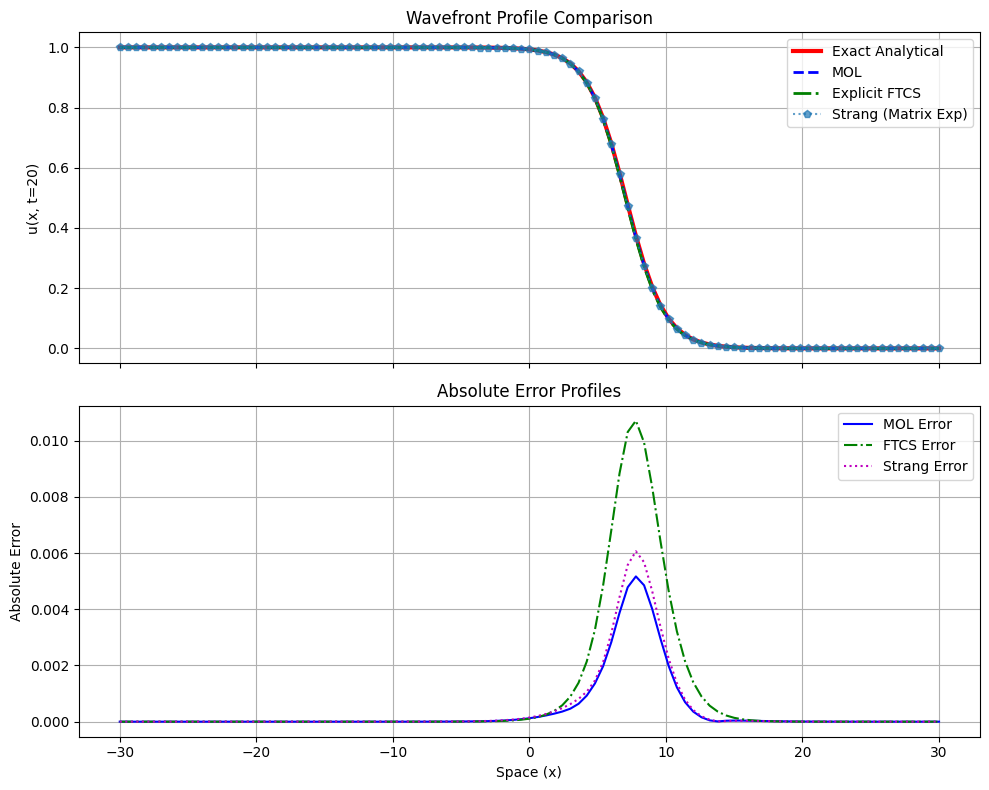

In [46]:
from scipy.linalg import expm  # Matrix exponential routine
# Universal Setup
a = 0.25
D = 1.0
nx = 101
xg = np.linspace(-30, 30, nx)
dx = xg[1] - xg[0]
t_final = 20.0

def ua_exact(x, t, a, D):
    term = x / np.sqrt(2 * D) + (a - 0.5) * t
    term = np.clip(term, -500, 500)
    return 1.0 / (1.0 + np.exp(term))

u0 = ua_exact(xg, 0.0, a, D)
u_exact_final = ua_exact(xg, t_final, a, D)

# 1. Method of Lines (MOL)
def fhn_mol(t, u):
    uxx = np.zeros(nx)
    uxx[1:-1] = (u[2:] - 2 * u[1:-1] + u[:-2]) / (dx**2)
    uxx[0] = 2 * (u[1] - u[0]) / (dx**2)
    uxx[-1] = 2 * (u[-2] - u[-1]) / (dx**2)
    return D * uxx - u * (1 - u) * (a - u)

t_start = time.time()
sol_mol = solve_ivp(fun=fhn_mol, t_span=(0, t_final), y0=u0, method='BDF')
time_mol = time.time() - t_start
u_mol = sol_mol.y[:, -1]
steps_mol = len(sol_mol.t)

# 2. Explicit FTCS
t_start = time.time()
dt_ftcs = (dx**2) / (2.0 * D) * 0.9
num_steps_ftcs = int(np.ceil(t_final / dt_ftcs))
dt_ftcs_actual = t_final / num_steps_ftcs

u_ftcs = u0.copy()
uxx = np.zeros(nx)
for n in range(num_steps_ftcs):
    uxx[1:-1] = (u_ftcs[2:] - 2 * u_ftcs[1:-1] + u_ftcs[:-2]) / (dx**2)
    uxx[0] = 2 * (u_ftcs[1] - u_ftcs[0]) / (dx**2)
    uxx[-1] = 2 * (u_ftcs[-2] - u_ftcs[-1]) / (dx**2)
    reaction = u_ftcs * (1 - u_ftcs) * (a - u_ftcs)
    u_ftcs = u_ftcs + dt_ftcs_actual * (D * uxx - reaction)
time_ftcs = time.time() - t_start
steps_ftcs = num_steps_ftcs

# 3. Operator Splitting (Strang Splitting) via STRATEGY 2 (Matrix Exponential)
def reaction_rk4(u_val, dt_step):
    def f(u_tmp): return -u_tmp * (1 - u_tmp) * (a - u_tmp)
    k1 = f(u_val)
    k2 = f(u_val + 0.5 * dt_step * k1)
    k3 = f(u_val + 0.5 * dt_step * k2)
    k4 = f(u_val + dt_step * k3)
    return u_val + (dt_step / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

t_start = time.time()
dt_strang = 0.5
num_steps_strang = int(t_final / dt_strang)

# --- PRE-COMPUTE DIFFUSION MATRIX & EXPONENTIAL ONCE ---
# Construct second-derivative finite difference matrix (L) with zero-flux Neumann bounds
L = np.zeros((nx, nx))
for i in range(1, nx-1):
    L[i, i-1] = 1.0
    L[i, i]   = -2.0
    L[i, i+1] = 1.0

# Incorporate boundaries into matrix rows
L[0, 0], L[0, 1] = -2.0, 2.0
L[-1, -2], L[-1, -1] = 2.0, -2.0

# Scale by continuous coefficients
L = (D / dx**2) * L

# Compute exact analytical linear operator propagator over a full step dt
Propagator = expm(L * dt_strang)
# --------------------------------------------------------

u_strang = u0.copy()
for n in range(num_steps_strang):
    # STEP 1: Half-step reaction
    u_star = reaction_rk4(u_strang, dt_strang / 2.0)

    # STEP 2: Full-step diffusion using single dot-product (Matrix multiplication)
    u_star_star = Propagator @ u_star

    # STEP 3: Remaining half-step reaction (Fixed loop indentation bug)
    u_strang = reaction_rk4(u_star_star, dt_strang / 2.0)

time_strang = time.time() - t_start
steps_strang = num_steps_strang

# Compute errors
err_mol_max = np.max(np.abs(u_mol - u_exact_final))
err_ftcs_max = np.max(np.abs(u_ftcs - u_exact_final))
err_strang_max = np.max(np.abs(u_strang - u_exact_final))

err_mol_rmse = np.sqrt(np.mean((u_mol - u_exact_final)**2))
err_ftcs_rmse = np.sqrt(np.mean((u_ftcs - u_exact_final)**2))
err_strang_rmse = np.sqrt(np.mean((u_strang - u_exact_final)**2))

# Build DataFrame table
df = pd.DataFrame({
    'Method': ['Method of Lines', 'Explicit FTCS', 'Strang (Matrix Exp)'],
    'Execution Time (s)': [time_mol, time_ftcs, time_strang],
    'Total Steps': [steps_mol, steps_ftcs, steps_strang],
    'Max Abs Error': [err_mol_max, err_ftcs_max, err_strang_max],
    'RMSE Error': [err_mol_rmse, err_ftcs_rmse, err_strang_rmse]
})
print(df.to_string(index=False))

# Plot side by side
%matplotlib inline
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(xg, u_exact_final, 'r-', linewidth=3, label='Exact Analytical')
axes[0].plot(xg, u_mol, 'b--', linewidth=2, label='MOL')
axes[0].plot(xg, u_ftcs, 'g-.', linewidth=2, label='Explicit FTCS')
axes[0].plot(xg, u_strang, 'p:', label='Strang (Matrix Exp)', alpha=0.7)
axes[0].set_ylabel('u(x, t=20)')
axes[0].set_title('Wavefront Profile Comparison')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(xg, np.abs(u_mol - u_exact_final), 'b-', label='MOL Error')
axes[1].plot(xg, np.abs(u_ftcs - u_exact_final), 'g-.', label='FTCS Error')
axes[1].plot(xg, np.abs(u_strang - u_exact_final), 'm:', label='Strang Error')
axes[1].set_ylabel('Absolute Error')
axes[1].set_xlabel('Space (x)')
axes[1].set_title('Absolute Error Profiles')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.savefig('fhn_notebook_comparison.png', dpi=300)
plt.show()